# Visualisation du modèle de diffusion wavelet

Ce notebook est adapté aux sorties de `wave_diffusion.py`.

Le modèle apprend la loi des détails d'ondelettes `cH/cV/cD` conditionnellement au prior basse fréquence `cA` :

```text
coeffs = [cA, cH, cV, cD]
prior  = coeffs[:, 0:1]
target = coeffs[:, 1:4]
```

Le notebook recharge les coefficients `j{niveau}_*.pt`, le checkpoint wavelet si présent, génère des détails conditionnés par des priors de validation, puis reconstruit des images via `pywt.idwt2`.


---
## Configuration


In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import pywt


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "wave_diffusion.py").exists() and (candidate / "lib").exists():
            return candidate
    raise RuntimeError("Impossible de trouver la racine du projet RT-Diffusion.")

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from lib.diffusion_lib.UNet import UNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PROJECT_ROOT =", project_root)
print("DEVICE =", DEVICE)


PROJECT_ROOT = /home/chapuissamuel/Documents/code/RT-Diffusion
DEVICE = cpu


In [2]:
def load_pt_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    return torch.load(path, map_location="cpu", weights_only=True)


def show_grid(images, n=16, cols=4, cmap="gray", seed=0, save=False, save_path="grid.png", title=None, colorbar=False):
    rng = np.random.default_rng(seed)
    total = images.shape[0]
    n = min(n, total)
    rows = int(np.ceil(n / cols))
    indices = rng.choice(total, size=n, replace=False)

    if colorbar:
        fig = plt.figure(figsize=(cols * 2.2 + 0.45, rows * 2.2), constrained_layout=True)
        gs = fig.add_gridspec(rows, cols + 1, width_ratios=[1] * cols + [0.06], wspace=0.02)
        axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(cols)] for r in range(rows)])
        cax = fig.add_subplot(gs[:, -1])
    else:
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2), squeeze=False, constrained_layout=True)
        cax = None

    im_ref = None
    for i, idx in enumerate(indices):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        img = images[idx].detach().cpu().numpy() if torch.is_tensor(images) else images[idx]
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]
        im_ref = ax.imshow(img, cmap=cmap)
        ax.set_title(f"idx={idx}")
        ax.axis("off")

    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=16)
    if colorbar and im_ref is not None:
        fig.colorbar(im_ref, cax=cax)
    if save:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


def print_dataset_summary(name, images):
    tensor = torch.as_tensor(images).float()
    print(
        f"{name:<12} shape={tuple(images.shape)!s:<18} dtype={images.dtype} "
        f"min={tensor.min().item():8.3f} max={tensor.max().item():8.3f} "
        f"mean={tensor.mean().item():8.3f} std={tensor.std().item():8.3f}"
    )


def normalize_generated_dataset(images, value_min=0, value_max=255):
    """Remet les sorties DDPM dans la convention uint8-like [0, 255] du dataset RT.

    La normalisation est faite image par image sur les deux dimensions spatiales,
    comme lors du preprocessing des champs RT.
    """
    data = images.float() if torch.is_tensor(images) else torch.as_tensor(images).float()
    reduce_dims = tuple(range(data.ndim)) if data.ndim <= 2 else (-2, -1)
    min_value = data.amin(dim=reduce_dims, keepdim=True)
    max_value = data.amax(dim=reduce_dims, keepdim=True)
    scale = max_value - min_value
    safe_scale = torch.where(scale == 0, torch.ones_like(scale), scale)
    normalized = (data - min_value) / safe_scale
    normalized = normalized * (value_max - value_min) + value_min
    return torch.where(scale == 0, torch.zeros_like(data), normalized)


In [ ]:
# Parametres a adapter selon l'experience wave_diffusion.py
WAVELET_LEVEL = 1
DATA_ROOT = project_root / "data" / "RT64" / "processed"

TRAIN_PT = DATA_ROOT / f"j{WAVELET_LEVEL}_training.pt"
VAL_PT = DATA_ROOT / f"j{WAVELET_LEVEL}_validation.pt"
TEST_PT = DATA_ROOT / f"j{WAVELET_LEVEL}_test.pt"

LOSS_CSV = project_root / "outputs" / "logs" /"cascade"/ f"wave_j{WAVELET_LEVEL}_RT64.csv"


# GENERATED_PT = project_root / "outputs" / "generated" / f"wave_j{WAVELET_LEVEL}_RT64.pt"
GENERATED_PT = project_root / "outputs" / "generated" /"cascade"/ f"j{WAVELET_LEVEL}_generated_coefficients.pt"

WAVELET = "db1"
BORDER_MODE = "periodization"
N_SAMPLES = 8
SEED = 0


In [4]:
def plot_loss_curve(csv_path):
    data = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    if "epoch" not in data.dtype.names or "train_loss" not in data.dtype.names:
        raise ValueError("Le CSV doit contenir les colonnes 'epoch' et 'train_loss'.")

    epochs = data["epoch"]
    train_loss = data["train_loss"]
    val_loss = data["val_loss"] if "val_loss" in data.dtype.names else None
    best_loss = data["best_loss"] if "best_loss" in data.dtype.names else None

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(epochs, train_loss, label="train_loss")
    if val_loss is not None:
        ax[0].plot(epochs, val_loss, label="val_loss", alpha=0.8)
    if best_loss is not None:
        ax[0].plot(epochs, best_loss, label="best_loss", alpha=0.8)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("RT28 loss")
    ax[0].legend()

    eps = 1e-12
    ax[1].plot(epochs, np.log(np.clip(train_loss, eps, None)), label="log(train_loss)")
    if val_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(val_loss, eps, None)), label="log(val_loss)", alpha=0.8)
    if best_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(best_loss, eps, None)), label="log(best_loss)", alpha=0.8)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Log loss")
    ax[1].set_title("RT28 log loss")
    ax[1].legend()

    fig.tight_layout()
    plt.show()


In [5]:
plot_loss_curve(LOSS_CSV)

FileNotFoundError: /home/chapuissamuel/Documents/code/RT-Diffusion/outputs/logs/wave_j1_RT64.csv not found.

In [ ]:
val = load_pt_dataset(VAL_PT)
gen = load_pt_dataset(GENERATED_PT)

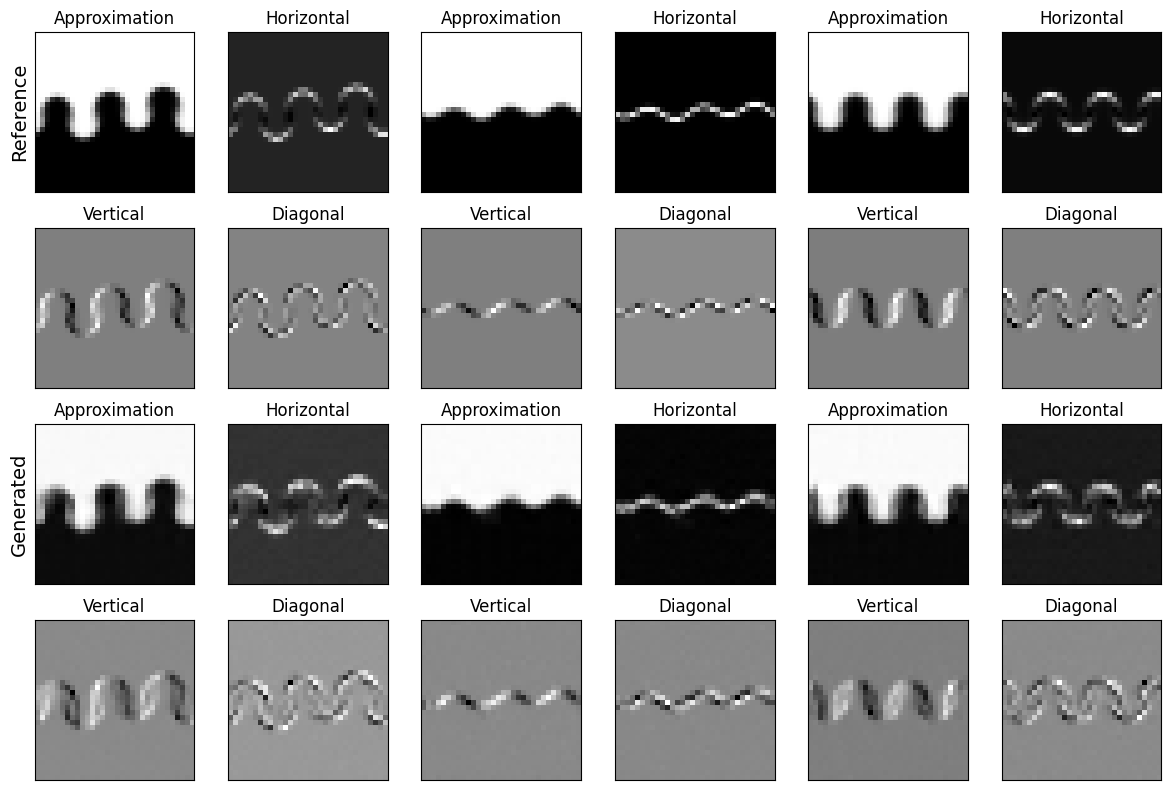

In [ ]:
import matplotlib.pyplot as plt

def plot_wavelet_comparison(real_data,
                            generated_data,
                            n_examples=3,
                            channel_titles=None,
                            cmap="gray"):
    """
    Compare des décompositions en ondelettes.

    Parameters
    ----------
    real_data : ndarray [N,4,H,W]
    generated_data : ndarray [N,4,H,W]
    n_examples : int
        Nombre d'exemples affichés par ligne.
    """

    if channel_titles is None:
        channel_titles = [
            "Approximation",
            "Horizontal",
            "Vertical",
            "Diagonal"
        ]

    fig, axes = plt.subplots(
        4,                      # 2 lignes * 2
        2 * n_examples,         # 3 blocs -> 6 colonnes
        figsize=(4*n_examples, 8)
    )

    datasets = [real_data, generated_data]
    row_names = ["Reference", "Generated"]

    for dataset_id, data in enumerate(datasets):

        # Ligne de blocs (0 ou 1)
        block_row = dataset_id

        for example in range(n_examples):

            coeffs = data[example]

            # Position du bloc
            r0 = block_row * 2
            c0 = example * 2

            # Approximation
            axes[r0, c0].imshow(coeffs[0], cmap=cmap)
            axes[r0, c0].set_title(channel_titles[0])

            # Horizontal
            axes[r0, c0 + 1].imshow(coeffs[1], cmap=cmap)
            axes[r0, c0 + 1].set_title(channel_titles[1])

            # Vertical
            axes[r0 + 1, c0].imshow(coeffs[2], cmap=cmap)
            axes[r0 + 1, c0].set_title(channel_titles[2])

            # Diagonal
            axes[r0 + 1, c0 + 1].imshow(coeffs[3], cmap=cmap)
            axes[r0 + 1, c0 + 1].set_title(channel_titles[3])

    # Nettoyage
    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    # Labels des deux jeux
    axes[0, 0].set_ylabel("Reference", fontsize=14)
    axes[2, 0].set_ylabel("Generated", fontsize=14)

    plt.tight_layout()
    plt.show()

plot_wavelet_comparison(val, gen, n_examples=3)

In [ ]:
def reconstruct_wavelet_sample(coeffs,
                               wavelet=WAVELET,
                               mode=BORDER_MODE):
    """
    coeffs : [4,H,W]
             [cA,cH,cV,cD]
    """

    cA = coeffs[0]
    cH = coeffs[1]
    cV = coeffs[2]
    cD = coeffs[3]

    return pywt.idwt2(
        (cA, (cH, cV, cD)),
        wavelet=wavelet,
        mode=mode
    )


def reconstruct_all_wavelet_samples(coeffs_array,
                                    wavelet=WAVELET,
                                    mode=BORDER_MODE):
    """
    coeffs_array : [N,4,H,W]
    """
    return np.array([
        reconstruct_wavelet_sample(coeffs, wavelet=wavelet, mode=mode)
        for coeffs in coeffs_array
    ])

real_img = reconstruct_all_wavelet_samples(val)
gen_img  = reconstruct_all_wavelet_samples(gen)

In [ ]:
from lib.PhyFID.metrics import compare_datasets

PHYFID_ENCODER = project_root / "outputs" / "phyFID" / "64phyfid_encoder.pt"
PHYFID_BATCH_SIZE = 128

phyfid_real = np.asarray(real_img, dtype=np.float32)
phyfid_generated = np.asarray(gen_img, dtype=np.float32)

print("Images PhyFID:", phyfid_real.shape, phyfid_generated.shape)

PHYFID_N_IMAGES = min(1000, len(phyfid_real) // 2, len(phyfid_generated))
phyfid_reference = phyfid_real[:PHYFID_N_IMAGES]

phyfid_datasets = {
    "val vs val": phyfid_real[PHYFID_N_IMAGES:2 * PHYFID_N_IMAGES],
    "val vs generated": phyfid_generated[:PHYFID_N_IMAGES]
}

phyfid_scores = {
    name: compare_datasets(phyfid_reference, dataset, PHYFID_ENCODER, batch_size=PHYFID_BATCH_SIZE)
    for name, dataset in phyfid_datasets.items()
}

print(f"Comparaison PhyFID sur {PHYFID_N_IMAGES} images")
for name, score in phyfid_scores.items():
    print(f"{name:<18} {score:>10.4f}")

Images PhyFID: (6528, 64, 64) (64, 64, 64)
Comparaison PhyFID sur 64 images
val vs val             0.3204
val vs generated       3.2618


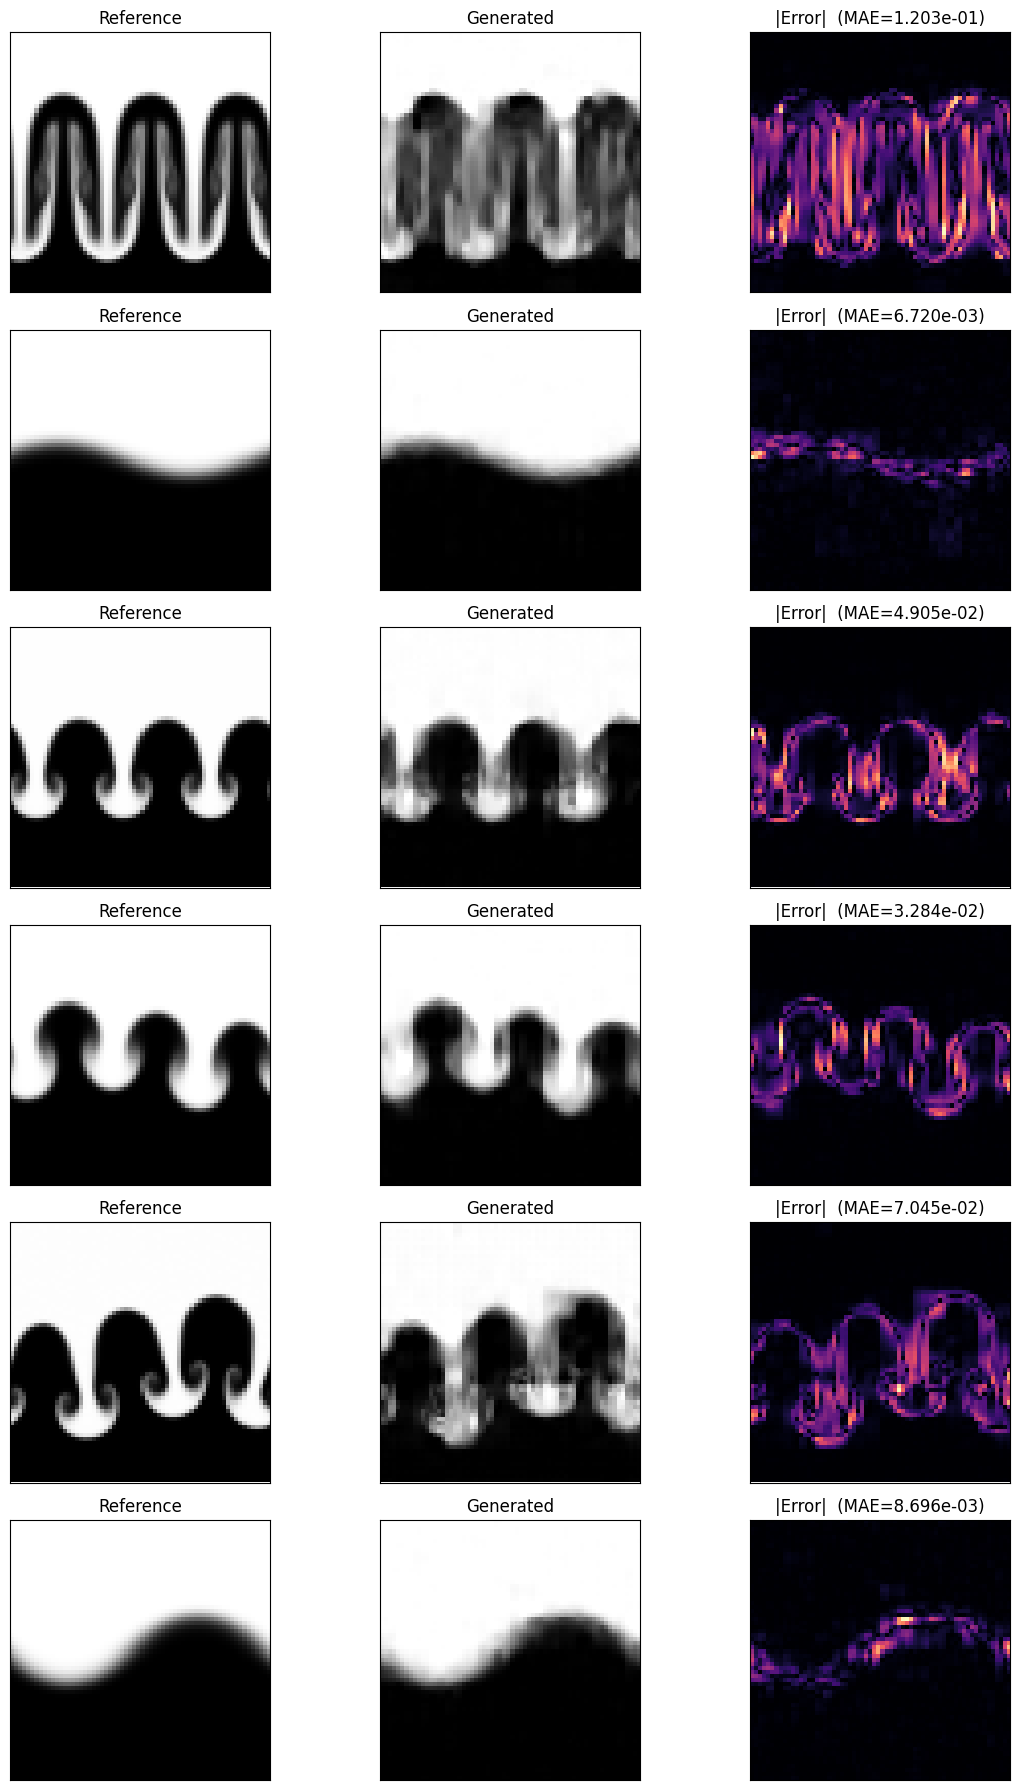

In [ ]:
def plot_reconstructed_comparison(real_coeffs,
                                  generated_coeffs,
                                  n_examples=4,
                                  cmap="gray"):

    fig, axes = plt.subplots(
        n_examples,
        3,
        figsize=(12, 3 * n_examples)
    )

    if n_examples == 1:
        axes = axes[None, :]

    rand_indices = np.random.choice(len(generated_coeffs), size=n_examples, replace=False)

    for i in range(n_examples):

        real_img = reconstruct_wavelet_sample(real_coeffs[rand_indices[i]])
        gen_img  = reconstruct_wavelet_sample(generated_coeffs[rand_indices[i]])

        err = np.abs(real_img - gen_img)

        # vmin = min(real_img.min(), gen_img.min())
        # vmax = max(real_img.max(), gen_img.max())

        vmin = 0
        vmax = 1

        im0 = axes[i, 0].imshow(
            real_img,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )
        axes[i, 0].set_title("Reference")

        im1 = axes[i, 1].imshow(
            gen_img,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )
        axes[i, 1].set_title("Generated")

        im2 = axes[i, 2].imshow(
            err,
            cmap="magma"
        )
        axes[i, 2].set_title(
            f"|Error|  (MAE={err.mean():.3e})"
        )

        for ax in axes[i]:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()


plot_reconstructed_comparison(
    val,
    gen,
    n_examples=6
)